# Kaggle diabetes prediction challenge: Submission template

Our lesson 20: classification activity will use an active Kaggle playground competition. Playground competitions run every month and highlight interesting/approachable datasets for the ML community to practice skills on a variety of ML problem types without the pressure, complexity and long duration of prize money competitions. 

It just so happens that this month's playground competition is a classification challenge! See the full competition details here: [Playground Series - Season 5, Episode 12: Diabetes Prediction Challenge](https://www.kaggle.com/competitions/playground-series-s5e12)

This notebook template will help you make your first Kaggle competition submission. It is pre-filled with code to load the competition data and output random predictions (see section 5. Submission below). This will score ~0.50 on the Kaggle public leaderboard. Your job is to improve that score with EDA, clever feature engineering and good model optimization. Good luck!

## How to submit on Kaggle

**1. Upload this notebook to Kaggle:**
   - Create a Kaggle account and log in to [kaggle](https://www.kaggle.com)
   - Click '+ Create' in the left navigation menu
   - Select 'Import Notebook' and upload this file (or link to GitHub)

**2. Start the notebook:**
   - Find your uploaded notebook in your Kaggle account under 'Code'
   - Click on the notebook to open it
   - The notebook will open in edit mode - you can now run cells and make changes

**3. Add the competition dataset:**
   - From the notebook environment, in the right sidebar, click the 'Input' tab
   - Click '+ Add Input' → filter by 'Competition Datasets'
   - Find 'Diabetes Prediction Challenge' and click the '+' icon
   - Note: You must join the competition first (click 'Join Competition' on the competition page)

**4. Access the data:**
   - Once added, the data is available at `/kaggle/input/playground-series-s5e12/`
   - Files: `train.csv` (training data with labels), `test.csv` (test data without labels), `sample_submission.csv` (submission format example)

**5. Make your submission:**
   - Your notebook must output test set predictions to `submission.csv` in the correct format
   - Go to 'Submit to competition' tab in the right sidebar and click 'Submit'

**Note:** This notebook uses a `KAGGLE` flag (under 'Run configuration') to switch between Kaggle and local file paths. Set it to `True` when running on Kaggle, or `False` when running locally with data in a `../data/` directory.

## Notebook set-up

### Imports

In [58]:
# Standard library imports
from pathlib import Path


import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import t
from scipy.stats import boxcox, yeojohnson, shapiro
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)
import platform
import sys
import platform
import sys

# How to tell python version
#print (sys.version_info)
#print (platform.python_version())

# How to pip install from Terminal window:
# python -m pip install seaborn

# Put this at the top of your notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)  # Set a large number
pd.set_option('display.max_colwidth', None)

# Set random seed for reproducibility
np.random.seed(315)

### Run configuration

In [59]:
# Set to True when running on Kaggle, False when running locally
KAGGLE = False

#####  **Utility Function Definitions** #####

In [60]:
def PrintDataFrameStatus(df_target):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()
    print(df_target.describe(include='all').T)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()
    df_target.info()
    print()
    print()

    print(f'df_floridabikerentals Shape:{df_target.shape}')
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])
    print()

    print('Do we have any features with nan values?:')
    print(df_target.isna().any().any())

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    print(df_target.sample(20))
    print


def ExamineCategoricalFeatures(df_train, df_test, feature_name):
    n_times = df_train[feature_name].nunique()
    values = df_train[feature_name].unique()
    print(f'Train:: {feature_name} -- There are: {n_times} unique times (times of day)')
    print(values)
    print()

    n_times = df_test[feature_name].nunique()
    values = df_test[feature_name].unique()
    print(f'Test:: {feature_name} -- There are: {n_times} unique times (times of day)')
    print(values)
    print()
    print()    


def DisplayTable(df_target, table_title=None):

    n_rows, n_cols = df_target.shape

    # Reduce extra figure padding by setting constrained_layout=True
    fig, ax = plt.subplots(
        figsize=(n_cols * 1.5, (n_rows + 1) * 0.55),
        constrained_layout=True
    )

    ax.axis('off')

    # Format floats dynamically to 2 decimals only if numeric
    cell_text = []
    for row in df_target.values:
        new_row = []
        for val in row:
            if isinstance(val, (float, int)):
                new_row.append(f"{val:.2f}")
            else:
                new_row.append(str(val))
        cell_text.append(new_row)

    table = ax.table(
        cellText=cell_text,
        colLabels=df_target.columns,
        cellLoc='center',
        loc='center'
    )

    # Bold column headers
    for col in range(n_cols):
        table[(0, col)].set_text_props(fontweight='bold')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(n_cols)))
    table.scale(1.2, 2.0)

    # Add title with tightened spacing
    if table_title is not None:
        ax.set_title(table_title, fontweight='bold', fontsize=14, pad=10)

    # Reduce extra whitespace explicitly
    plt.subplots_adjust(top=0.88, bottom=0.08)

    plt.show()


def DisplayNumericFeatureHistgorams(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True, batch_size=15):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    total_cols = len(cols_to_plot)
    total_batches = (total_cols + batch_size - 1) // batch_size

    # Process in batches
    for batch_num, batch_start in enumerate(range(0, total_cols, batch_size), 1):
        batch_cols = cols_to_plot[batch_start:batch_start + batch_size]
        number_of_cols = len(batch_cols)

        ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
        nrows = (number_of_cols + ncols - 1) // ncols

        # I need a 3 column plot
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        if number_of_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        # Iterate over each numeric column and plot a historbram
        for i, col in enumerate(batch_cols):

            try:
                sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

                axes[i].set_xlabel(col, fontweight='bold')
                axes[i].set_ylabel('Count', fontweight='bold')
                data = df_target[col]

                if display_statistics == True:

                    min_val = data.min()
                    max_val = data.max()
                    range_val = data.max() - data.min()
                    mean_val = data.mean()
                    median_val = data.median()
                    mode_val = data.mode().tolist()
                    std_val = data.std()
                    quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
                    skew_val = data.skew()
                    kurtosis_val = data.kurtosis()

                    stats = {
                        'Feature': col,
                        'Min': min_val,
                        'Max': max_val,
                        'Mean': mean_val,
                        'Median': median_val,
                        'Mode': mode_val,
                        'Std': std_val,
                        'Range': range_val,
                        'Quantile': quantile_val,
                        'Skew': skew_val,
                        'Kurtosis': kurtosis_val
                    }            

                    statistics.append(stats)

                    # print(f'Min Value: {min_val:.3f}')
                    # print(f'Max Value: {max_val:.3f}')
                    # print(f'Mean Value: {mean_val:.3f}')
                    # print(f'Median Value: {median_val:.3f}')
                    # print(f'Mode Value: {mode_val}')
                    # print(f'Standard Deviation: {std_val:.3f}')
                    # print(f'Range Value = {range_val:.3f}')
                    # print(f'Quantile Value = {quantile_val}')
                    # print(f'Skew Value: {skew_val:.3f}')
                    # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

                    axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

                    # Vertical lines for mean and median, shaded std
                    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
                    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
                    axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

                else:
                    axes[i].set_title(f'{col}', fontweight='bold')
                
                # Tick labels in bold
                axes[i].tick_params(axis='both', labelsize=10)
                for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
                    label.set_fontweight('bold')

            except Exception as ex:
                print(f"Warning: Unexpected error - {ex}")
                continue

        # Hide the blank/empty graphs
        for j in range(number_of_cols, len(axes)):
            fig.delaxes(axes[j])

        # Make plots more readable and add space
        title = None
        # Make plots more readable and add space
        title = None
        if plot_title is None:
            title = f'Histograms for Numeric Features of {data_set_name} (Batch {batch_num}/{total_batches})'
        else:
            title = f'Histograms for Numeric Features of {data_set_name} :: {plot_title} (Batch {batch_num}/{total_batches})'

        plt.suptitle(title, fontweight='bold')

        plt.suptitle(title)
        plt.subplots_adjust(top=0.92)  

        plt.tight_layout(h_pad=5)
        plt.show()
        plt.close(fig)

        print()
        print()

    if display_statistics == True:
        df_statistics = pd.DataFrame(statistics)
        DisplayTable(df_statistics, 'Numeric Features Statistics')

def PlotBoxPlotsToViewDistributions(df_target, feature_columns = None, target_label=None, plot_title=None, batch_size=15):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    total_cols = len(cols_to_plot)
    total_batches = (total_cols + batch_size - 1) // batch_size

    # Process in batches
    for batch_num, batch_start in enumerate(range(0, total_cols, batch_size), 1):
        batch_cols = cols_to_plot[batch_start:batch_start + batch_size]
        number_of_cols = len(batch_cols)

        ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
        nrows = (number_of_cols + ncols - 1) // ncols

        # I need a 3X4 plot to display 10 histograms
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        if number_of_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        #Iterate over each numeric column and plot a historgram
        for i, col in enumerate(batch_cols):

            sns.boxplot(data=df_target, y=col, ax=axes[i])    
            axes[i].set_title(col, fontweight='bold')

            # Optional: Add count of outliers
            Q1 = df_target[col].quantile(0.25)
            Q3 = df_target[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outlier_count = len(df_target[(df_target[col] < lower) | 
                                                (df_target[col] > upper)])
            axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                        transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')

        # Hide the blank/empty graphs
        for j in range(number_of_cols, len(axes)):
            fig.delaxes(axes[j])        

        # Make plots more readable and add space
        title = None
        if plot_title is None:
            title = f'BoxPlots for Features of {data_set_name} (Batch {batch_num}/{total_batches})'
        else:
            title = f'BoxPlots for Features of {data_set_name} :: {plot_title} (Batch {batch_num}/{total_batches})'

        plt.suptitle(title, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top
        #plt.subplots_adjust(top=0.92)        

        # Make plots more readable and add space
        plt.tight_layout(h_pad=5)
        plt.show()
        plt.close(fig)

        print()
        print()        


def DisplayBarCountPlotsOfCategoricFeatures(df_target, feature_columns = None, target_label=None, plot_title=None, display_bar_labels=True, batch_size=15):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['object']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.remove(target_label)
    
    total_cols = len(cols_to_plot)
    total_batches = (total_cols + batch_size - 1) // batch_size

    # Process in batches
    for batch_num, batch_start in enumerate(range(0, total_cols, batch_size), 1):
        batch_cols = cols_to_plot[batch_start:batch_start + batch_size]
        number_of_cols = len(batch_cols)

        ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
        nrows = (number_of_cols + ncols - 1) // ncols

        # I need a 3 column plot
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        if number_of_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        # Iterate over each numeric column and plot a historbram
        for i, col in enumerate(batch_cols):
            
            sns.countplot(data=df_target, x=col, ax=axes[i])

            axes[i].set_title(col, fontweight='bold')
            axes[i].set_xlabel(col, fontweight='bold')
            axes[i].set_ylabel('Count', fontweight='bold')

            if display_bar_labels == True:
                # Add count labels on bars
                axes[i].bar_label(axes[i].containers[0], label_type='center', fontsize=8, rotation=90, fmt='%d', color='white')

            # Tick labels in bold
            axes[i].tick_params(axis='both', labelsize=10)
            for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
                label.set_fontweight('bold')            

        # Hide the blank/empty graphs
        for j in range(number_of_cols, len(axes)):
            fig.delaxes(axes[j])

        title = None
        if plot_title is None:
            title = f'Bar Count Plots for Categoric Features of {data_set_name} (Batch {batch_num}/{total_batches})'
        else:
            title = f'Bar Count Plots for Categoric Features of {data_set_name} :: {plot_title} (Batch {batch_num}/{total_batches})'
        
        # Make plots more readable and add space
        plt.suptitle(title, fontweight='bold')
        plt.subplots_adjust(top=0.92)  
        
        plt.tight_layout(h_pad=5)
        plt.show()
        plt.close(fig)

        print()
        print()



### Data loading

In [61]:
# Set file paths based on environment
if KAGGLE:
    # Kaggle paths - data is in /kaggle/input/
    train_df_path = '/kaggle/input/playground-series-s5e12/train.csv'
    test_df_path = '/kaggle/input/playground-series-s5e12/test.csv'

else:
    # Otherwise, load data from course GitHub repository
    train_df_path = 'diabetes_prediction_train.csv'
    test_df_path = 'diabetes_prediction_test.csv'

# Load the training and testing datasets
df_train = pd.read_csv(train_df_path)
df_test = pd.read_csv(test_df_path)

# Display first few rows of training data
#train_df.head()

data_set_name = 'Diabetes Prediction'

feature_label = 'diagnosed_diabetes'

##### Examine **Training Dataset** #####

In [62]:
PrintDataFrameStatus(df_train)

***********************************
Description Stats
***********************************

                                       count unique         top    freq        mean            std    min        25%       50%        75%       max
id                                  700000.0    NaN         NaN     NaN    349999.5  202072.738554    0.0  174999.75  349999.5  524999.25  699999.0
age                                 700000.0    NaN         NaN     NaN   50.359734       11.65552   19.0       42.0      50.0       58.0      89.0
alcohol_consumption_per_week        700000.0    NaN         NaN     NaN    2.072411       1.048189    1.0        1.0       2.0        3.0       9.0
physical_activity_minutes_per_week  700000.0    NaN         NaN     NaN   80.230803      51.195071    1.0       49.0      71.0       96.0     747.0
diet_score                          700000.0    NaN         NaN     NaN    5.963695       1.463336    0.1        5.0       6.0        7.0       9.9
sleep_hours_per_day  

##### Examine **Test Dataset** #####

In [63]:
PrintDataFrameStatus(df_test)

***********************************
Description Stats
***********************************

                                       count unique         top    freq        mean           std       min        25%       50%        75%       max
id                                  300000.0    NaN         NaN     NaN    849999.5  86602.684716  700000.0  774999.75  849999.5  924999.25  999999.0
age                                 300000.0    NaN         NaN     NaN   50.432397     11.938741      19.0       42.0      50.0       59.0      89.0
alcohol_consumption_per_week        300000.0    NaN         NaN     NaN    2.089693      1.066214       1.0        1.0       2.0        3.0       9.0
physical_activity_minutes_per_week  300000.0    NaN         NaN     NaN   92.349087     62.187399       1.0       51.0      77.0      115.0     748.0
diet_score                          300000.0    NaN         NaN     NaN    5.945838      1.481068       0.1        5.0       6.0        7.0       9.9
sleep_hou

## 1. EDA

#### **Potential Data Issues from Imported Data** ####
    The following columns (features) have missing data:
        There are no features with missing/null/<nan> data.
    
##### **Validate Data Features** #####
    Test each categorical feature to ensure it's context and validity

In [64]:
print('==========================================================================')

categorical_features=['gender','ethnicity','education_level','income_level','smoking_status','employment_status',]

for i, feature_name in enumerate(categorical_features):
    ExamineCategoricalFeatures(df_train, df_test, feature_name)

print()
print()    

Train:: gender -- There are: 3 unique times (times of day)
['Female' 'Male' 'Other']

Test:: gender -- There are: 3 unique times (times of day)
['Female' 'Male' 'Other']


Train:: ethnicity -- There are: 5 unique times (times of day)
['Hispanic' 'White' 'Asian' 'Black' 'Other']

Test:: ethnicity -- There are: 5 unique times (times of day)
['White' 'Hispanic' 'Black' 'Asian' 'Other']


Train:: education_level -- There are: 4 unique times (times of day)
['Highschool' 'Graduate' 'Postgraduate' 'No formal']

Test:: education_level -- There are: 4 unique times (times of day)
['Highschool' 'Graduate' 'Postgraduate' 'No formal']


Train:: income_level -- There are: 5 unique times (times of day)
['Lower-Middle' 'Upper-Middle' 'Low' 'Middle' 'High']

Test:: income_level -- There are: 5 unique times (times of day)
['Middle' 'Low' 'Lower-Middle' 'Upper-Middle' 'High']


Train:: smoking_status -- There are: 3 unique times (times of day)
['Current' 'Never' 'Former']

Test:: smoking_status -- There 

##### **Drop ID Column - Not used/useful** #####

In [65]:
df_train.drop(columns='id', inplace=True)
df_test.drop(columns='id', inplace=True)

#### <b>Initial Histograms of Raw Numeric Features</b> ####

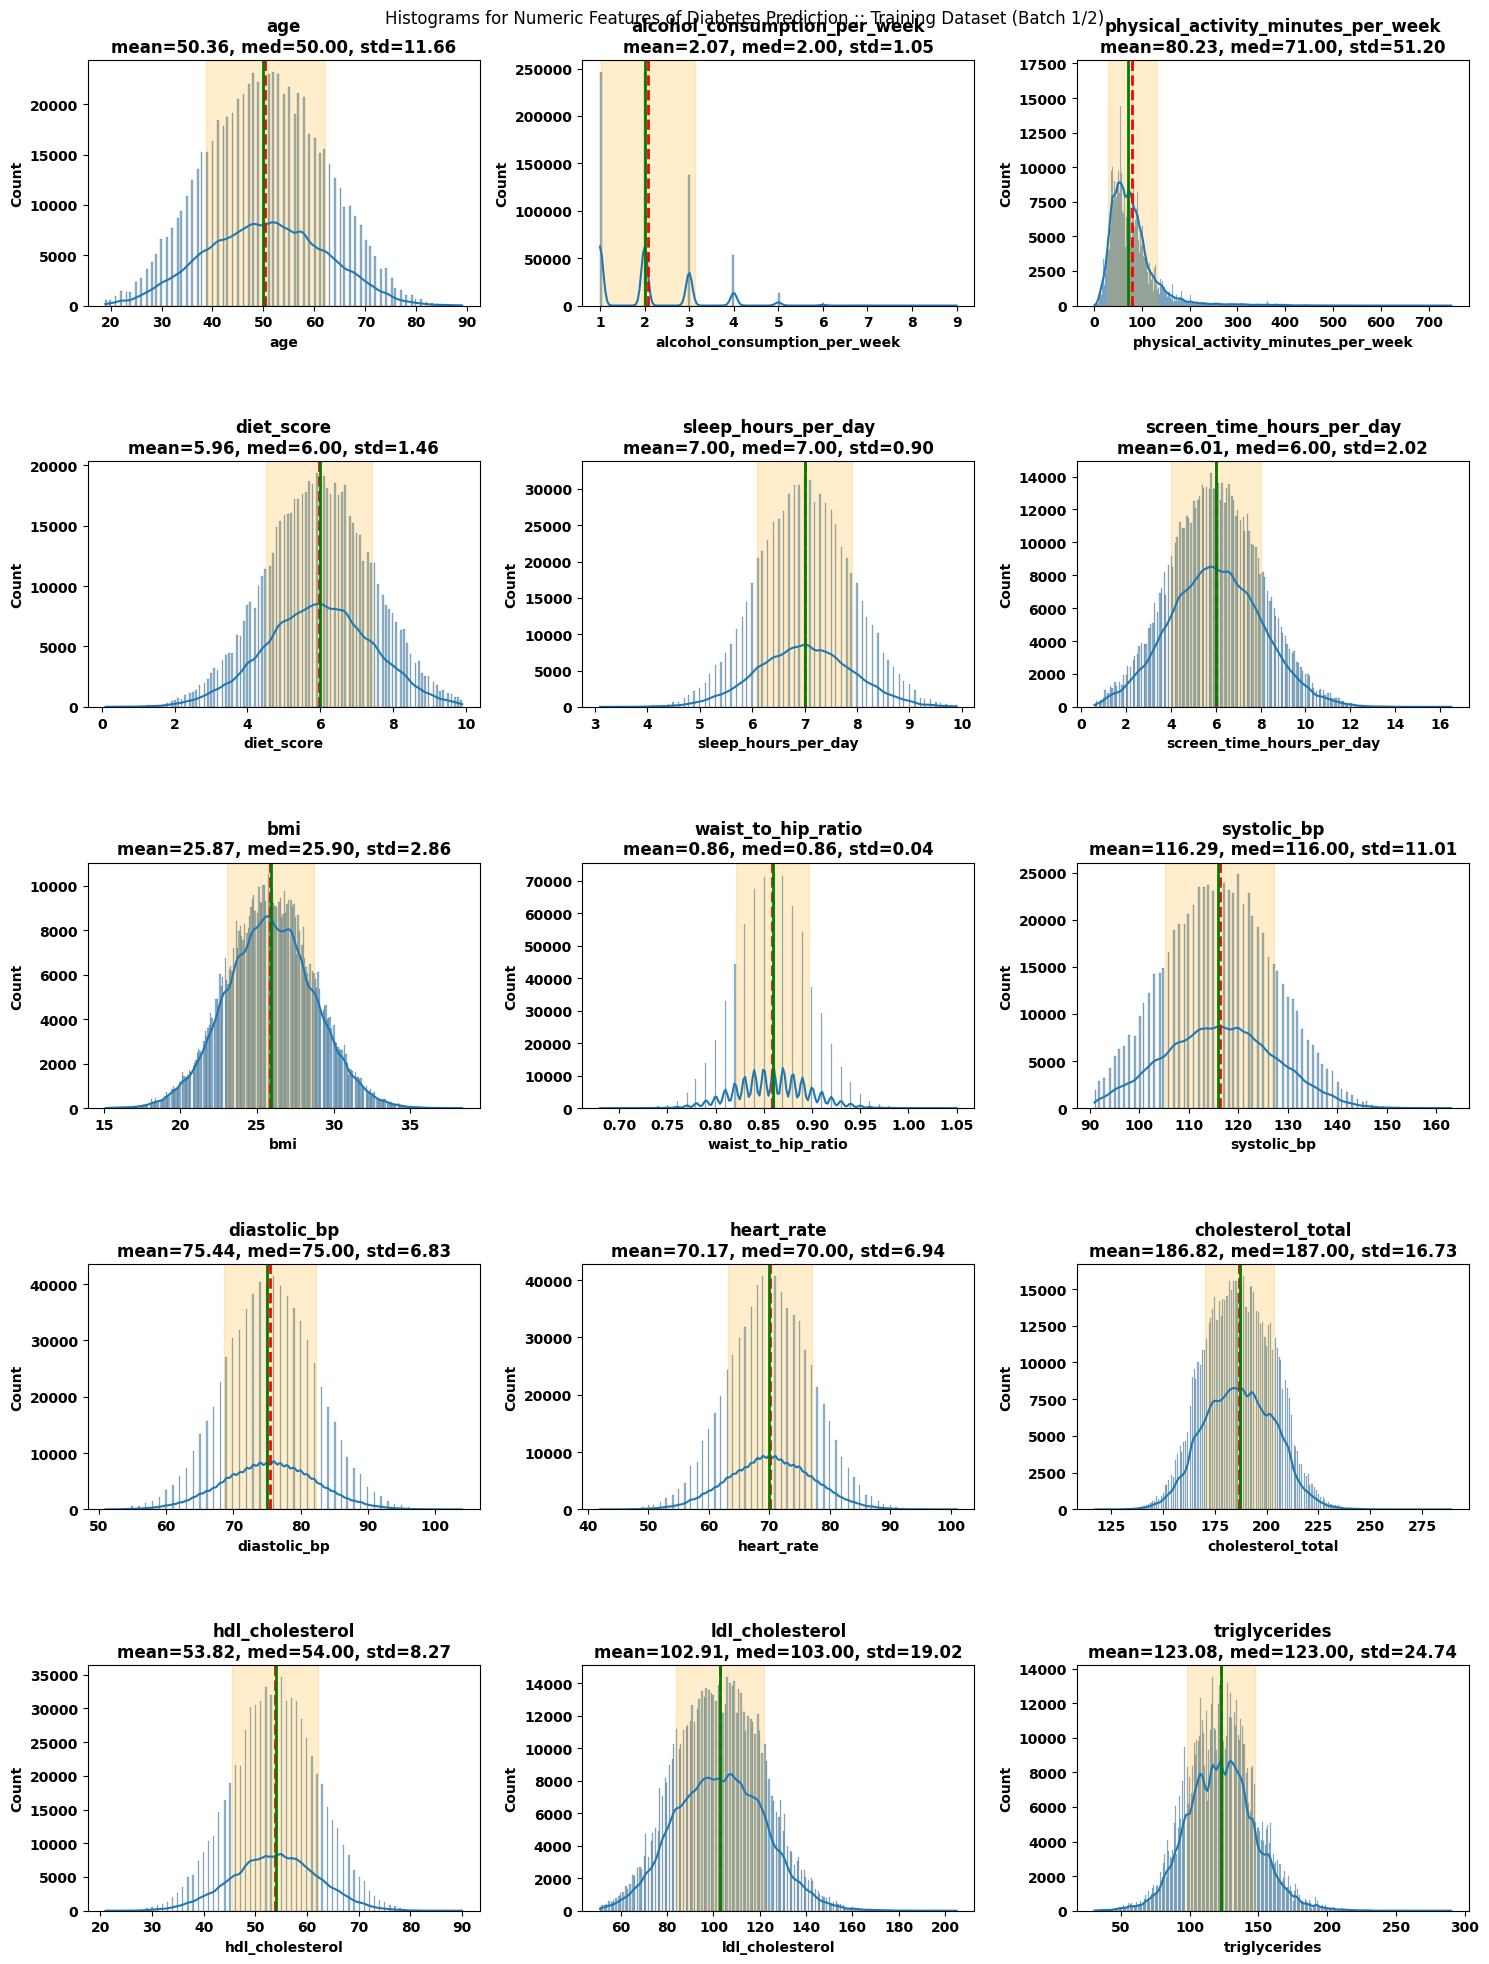

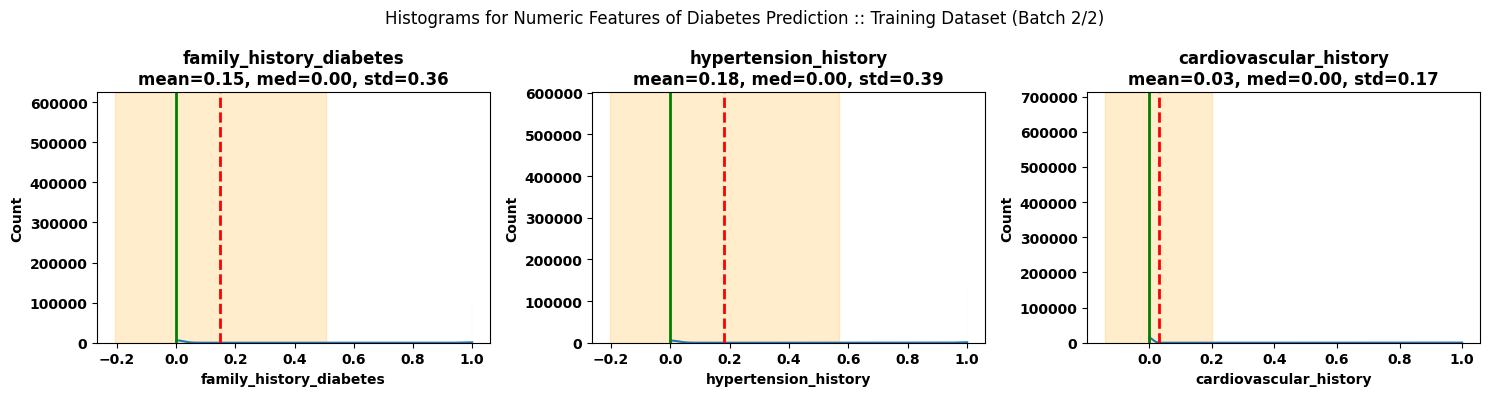

C:\Users\jxbma\AppData\Local\Temp\ipykernel_42024\721631526.py:107: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.88, bottom=0.08)


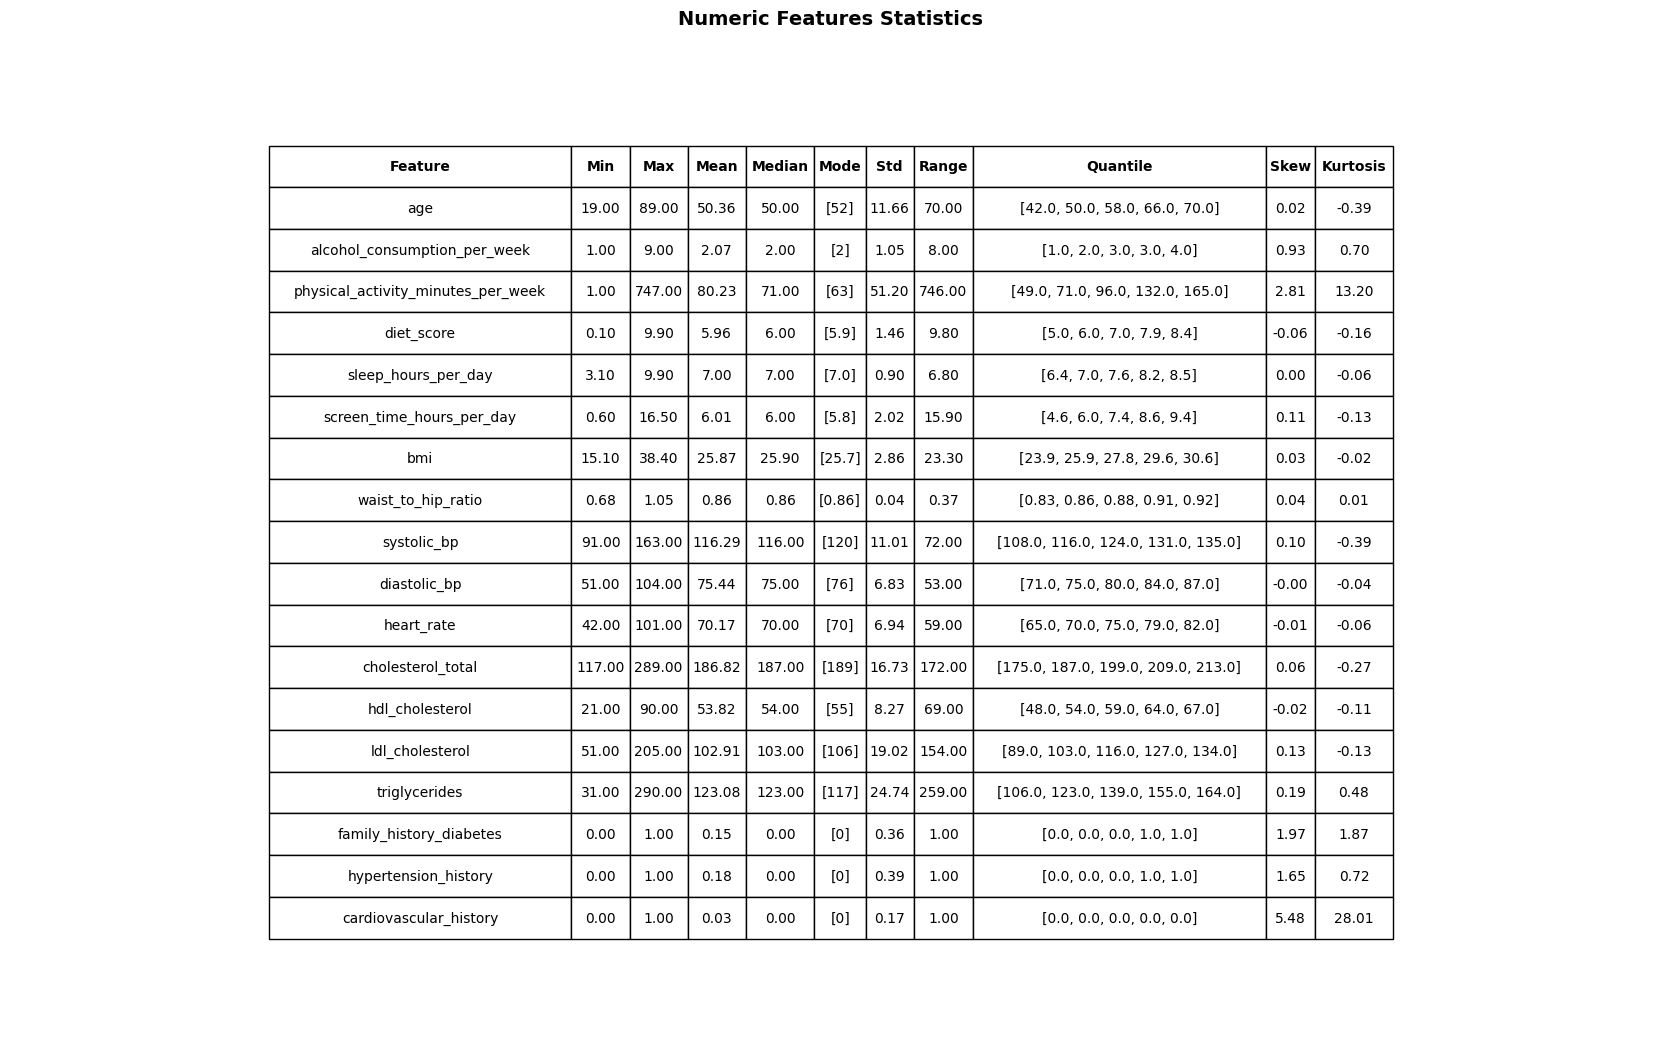

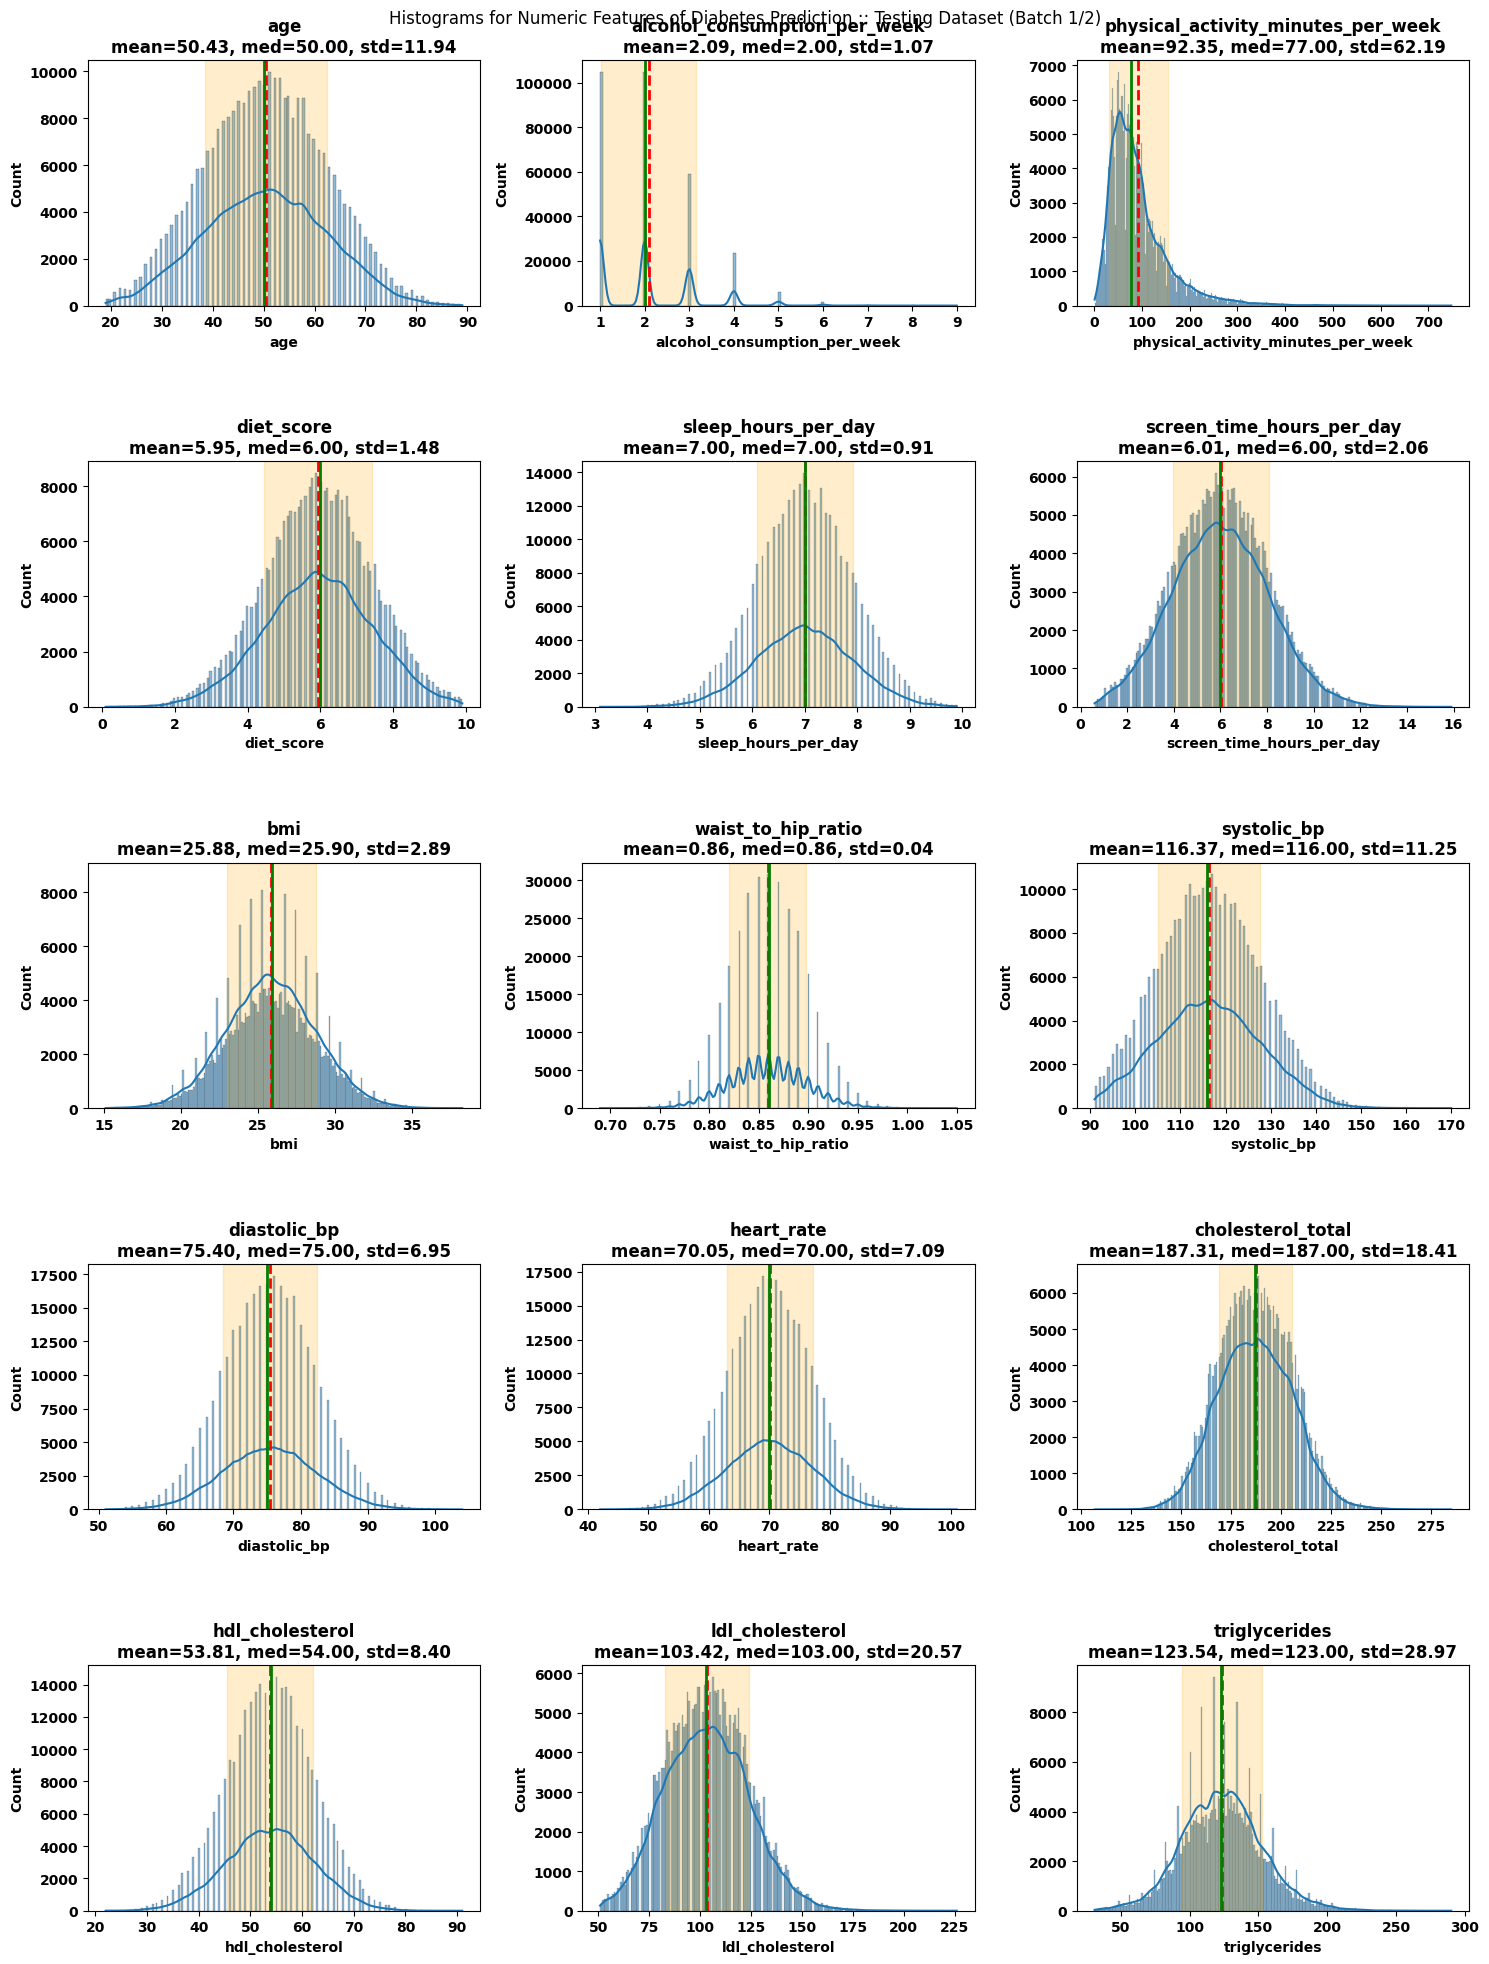

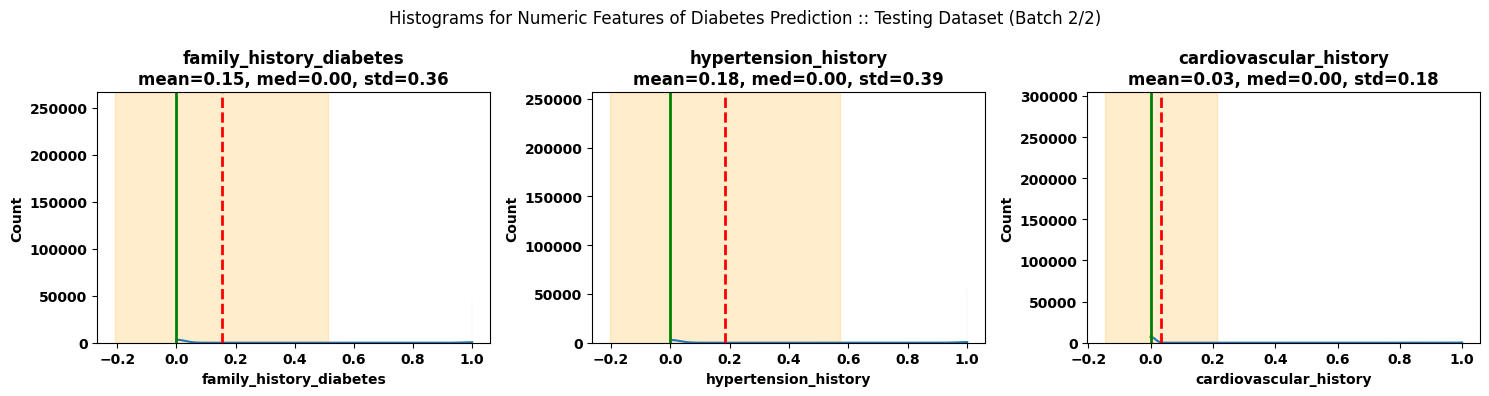

C:\Users\jxbma\AppData\Local\Temp\ipykernel_42024\721631526.py:107: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.88, bottom=0.08)


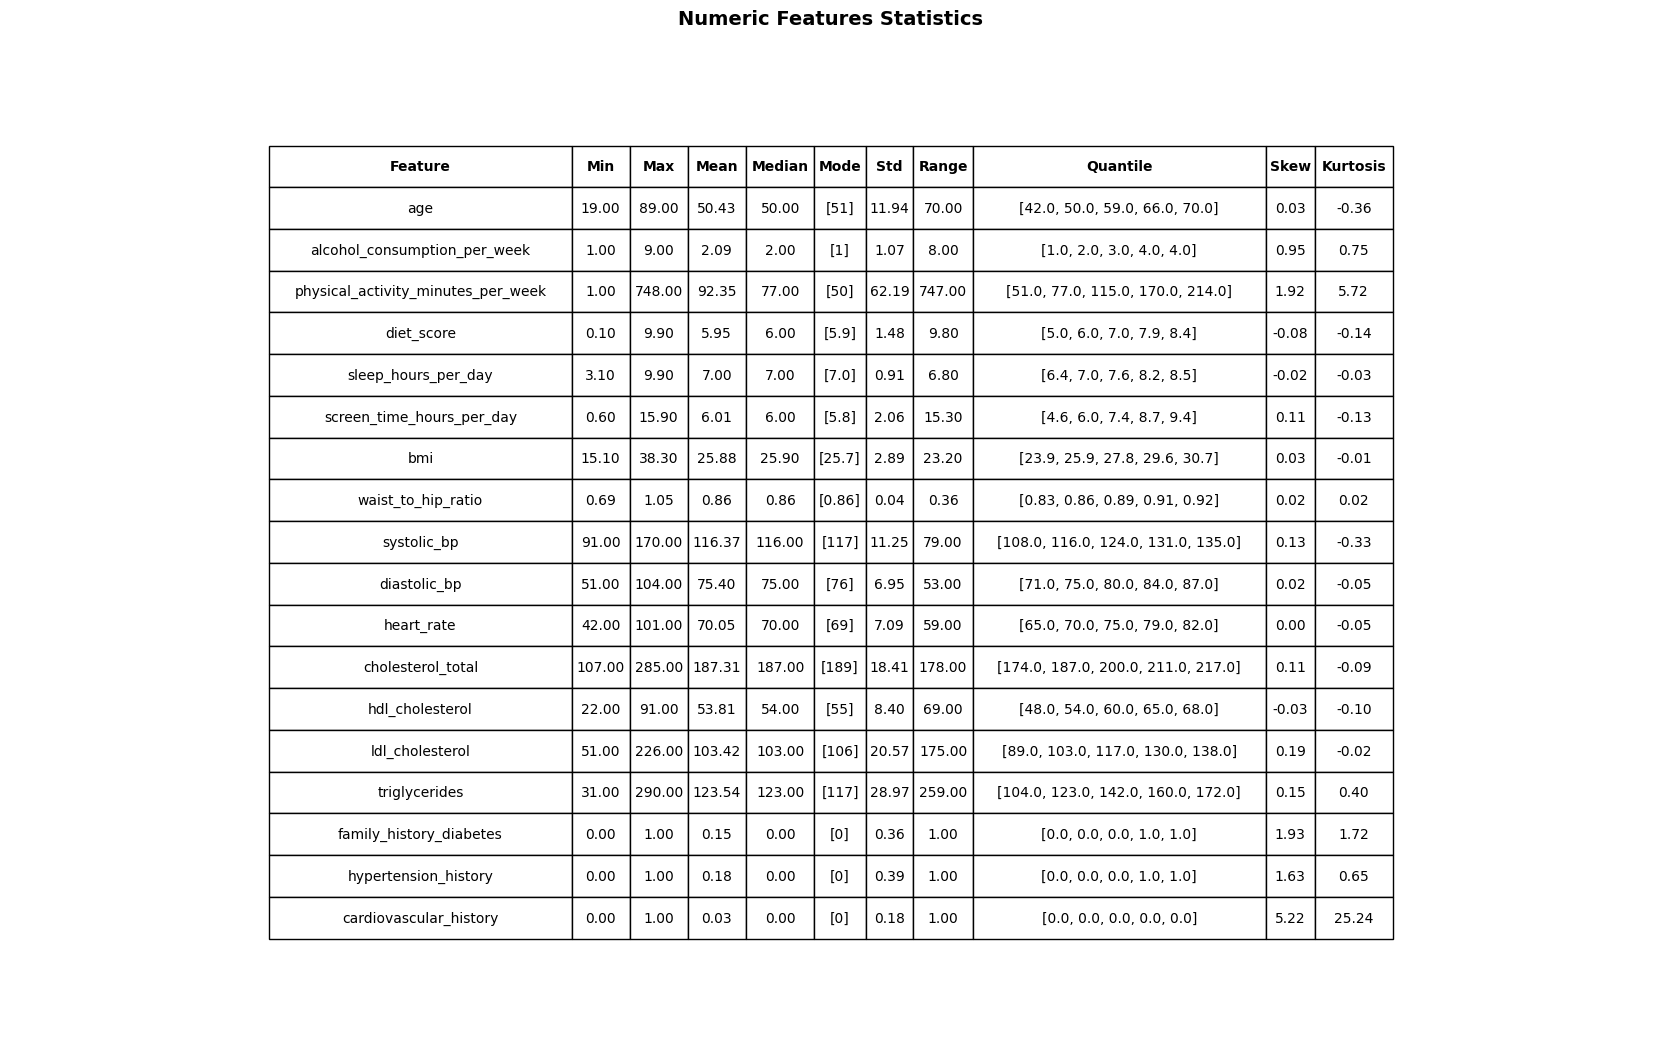

In [66]:
#
DisplayNumericFeatureHistgorams(df_train, target_label=feature_label, plot_title='Training Dataset') 
print()
print()

DisplayNumericFeatureHistgorams(df_test, plot_title='Testing Dataset') 
print()
print()

#### <b>Initial BoxPlots of Raw Numeric Features</b> ####
Help check for outliers

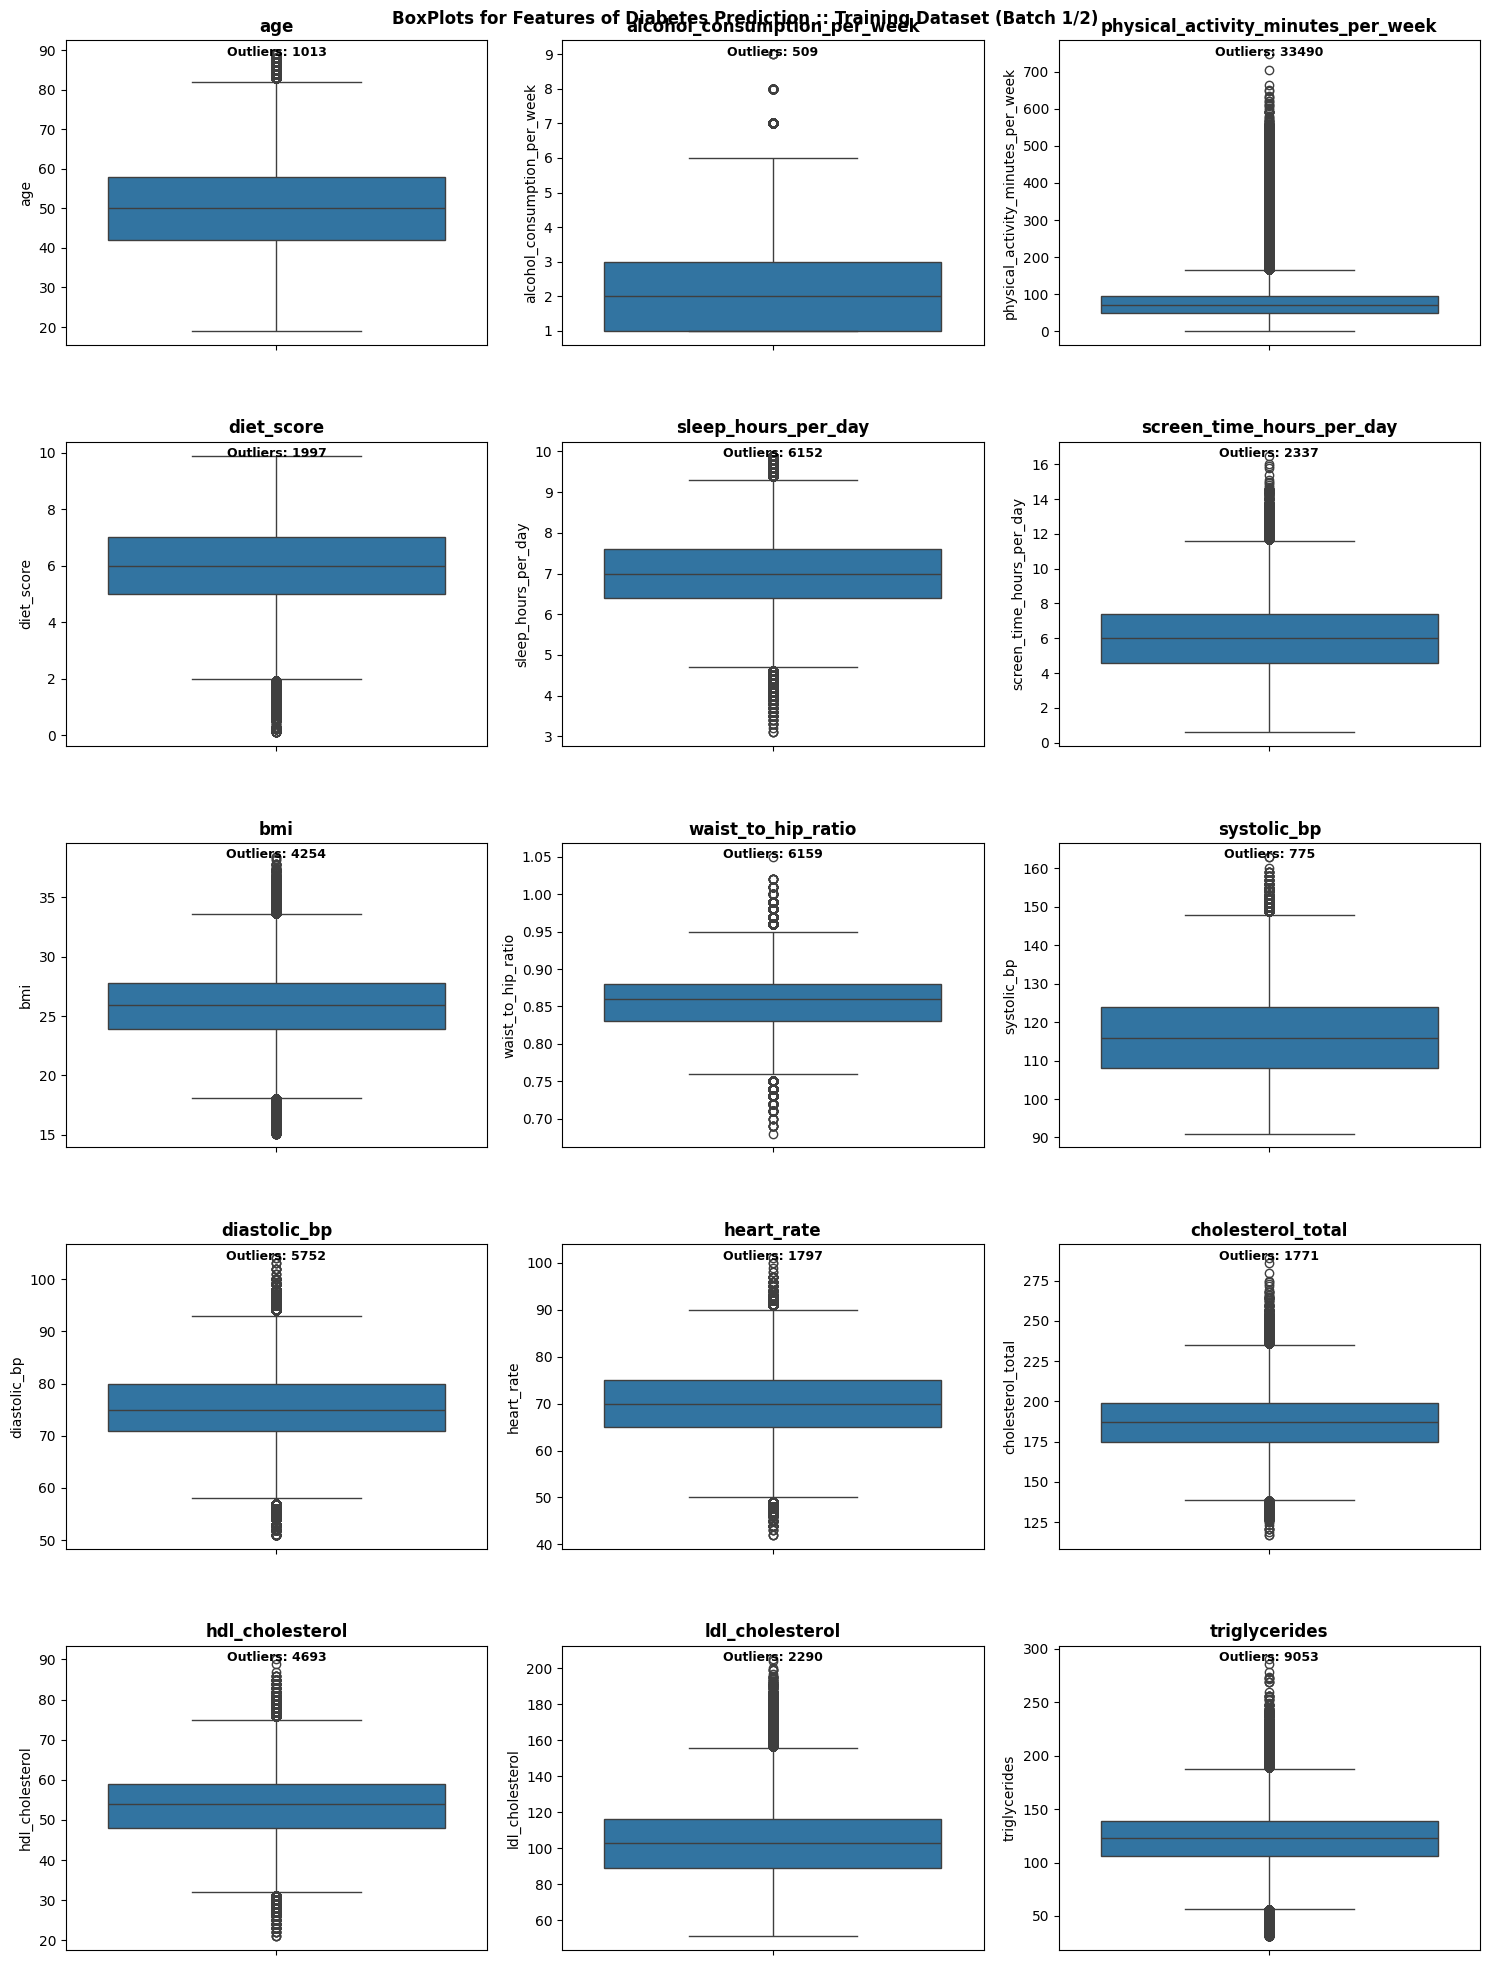

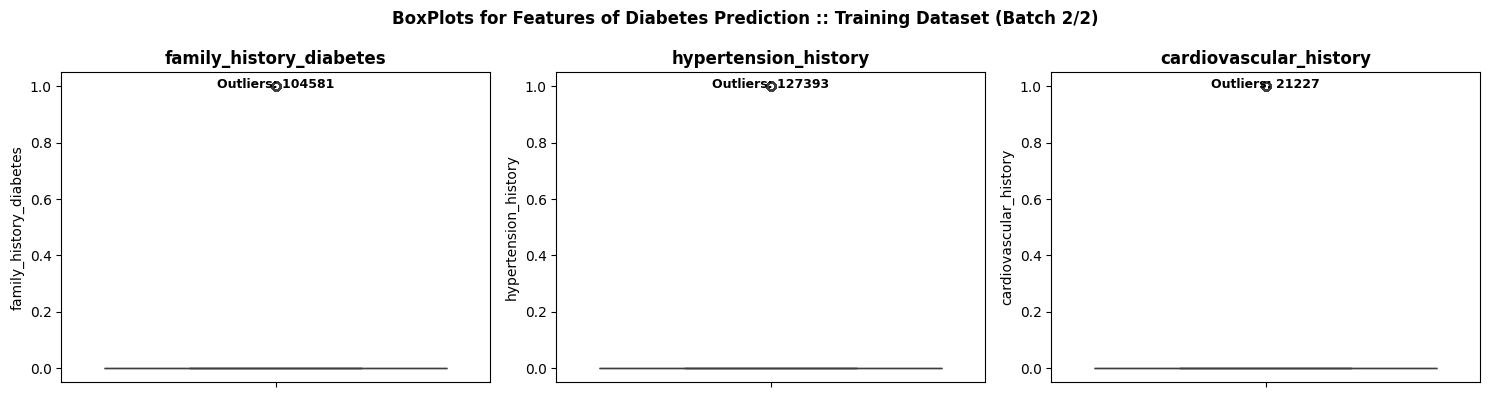

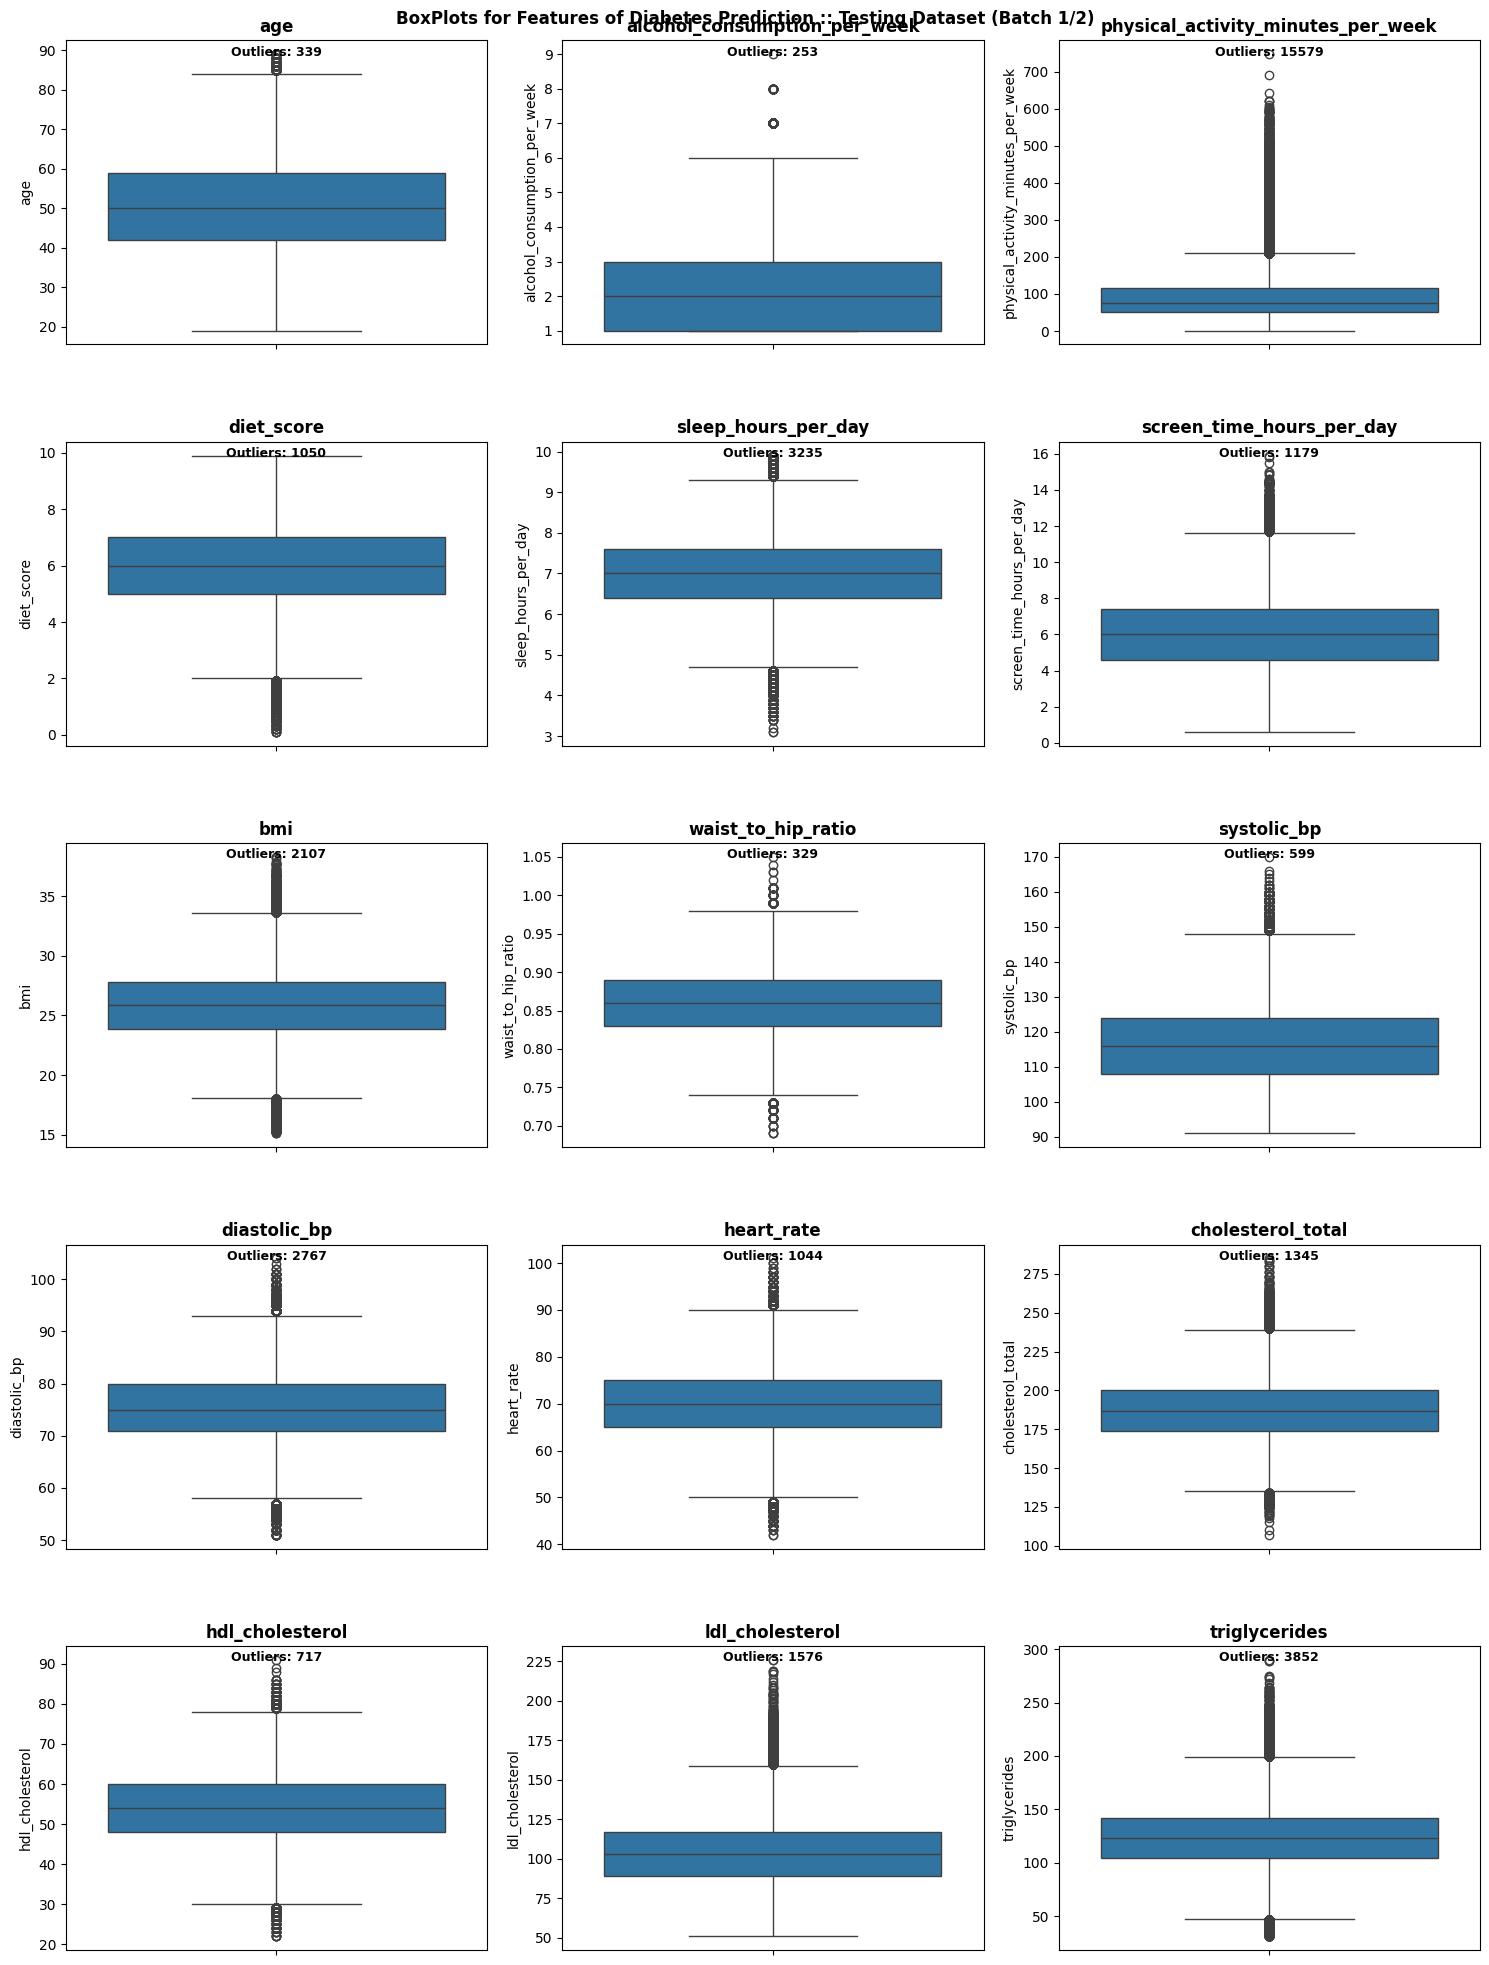

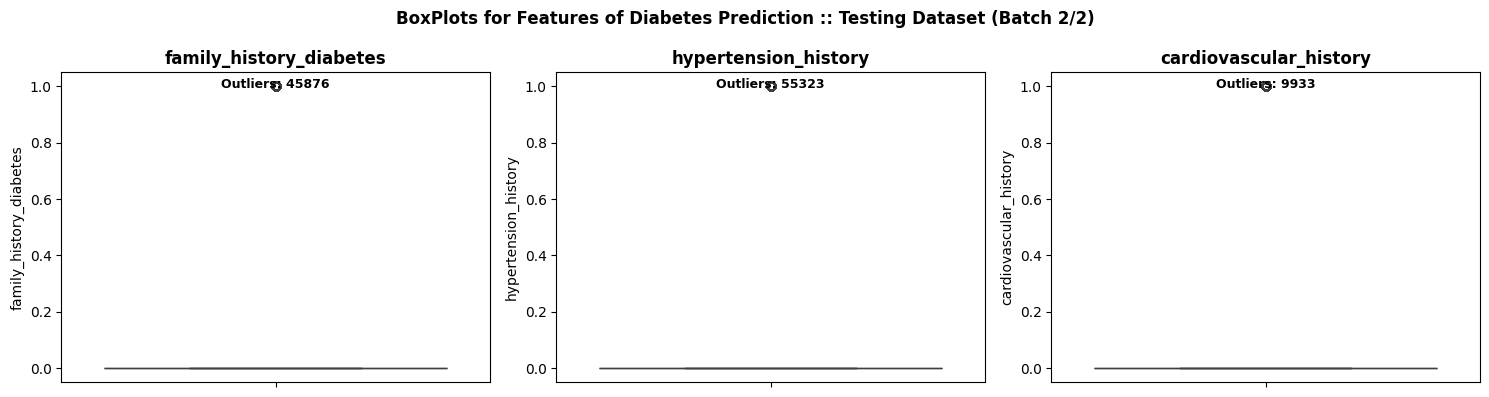

In [67]:
PlotBoxPlotsToViewDistributions(df_train, target_label=feature_label, plot_title='Training Dataset')
print()
print()

PlotBoxPlotsToViewDistributions(df_test, plot_title='Testing Dataset')
print()
print()

#### <b>Initial BarCount Plot of Raw Numeric Features</b> ####

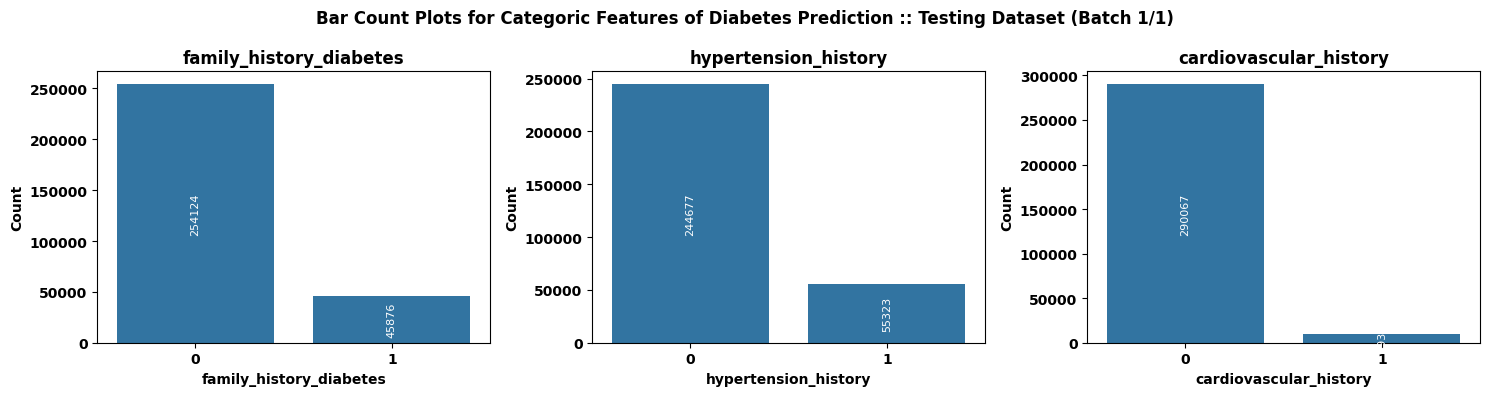

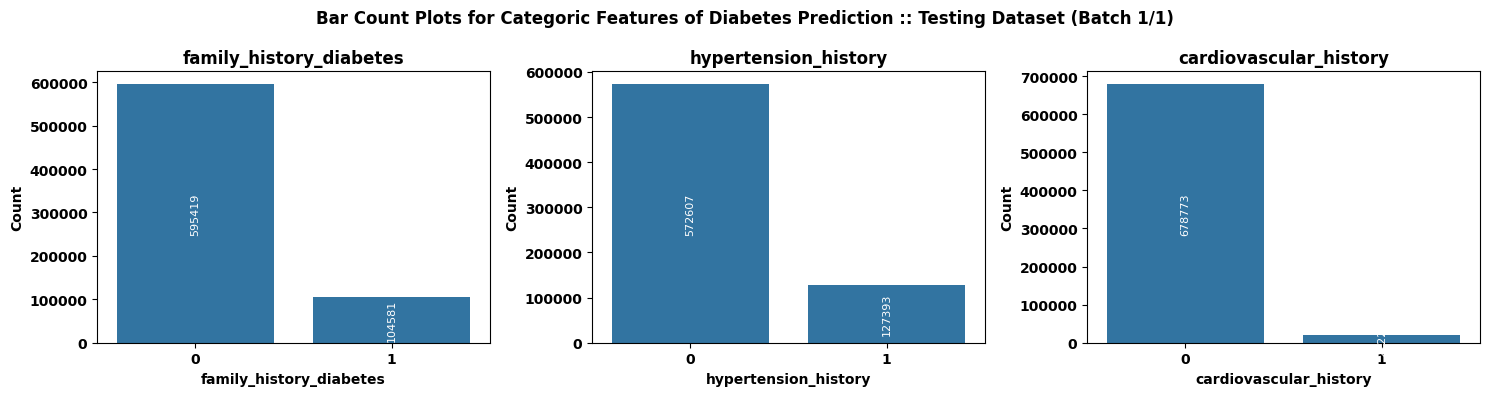

In [70]:
countable_features = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
DisplayBarCountPlotsOfCategoricFeatures(df_test, countable_features, plot_title='Testing Dataset' )
print()
print() 

DisplayBarCountPlotsOfCategoricFeatures(df_train, countable_features, plot_title='Testing Dataset' )
print()
print()

## 2. Feature engineering

In [71]:
# Your code here...

## 3. Model building

In [72]:
# Your code here...

## 4. Model evaluation

In [73]:
# Your code here...

## 5. Submission

In [74]:
# Make random predictions for submission by sampling from the training labels
# Note: Replace this with your model's predictions!
predictions = df_train['diagnosed_diabetes'].sample(n=test_df.shape[0], random_state=42).astype(int)
prediction_ids = df_test['id'].astype(int)

# Create submission DataFrame with required format: id, diagnosed_diabetes
submission_df = pd.DataFrame({
    'id': prediction_ids.values,
    'diagnosed_diabetes': predictions.values
})

# Determine output path based on environment
if KAGGLE:

    # On Kaggle, save to current directory for submission
    submission_file = 'submission.csv'

else:

    # Locally, save to ../data/ directory
    # Create directory if it doesn't exist
    data_dir = Path('../data')
    data_dir.mkdir(parents=True, exist_ok=True)
    submission_file = data_dir / 'submission.csv'

# Save submission file and display preview
submission_df.to_csv(submission_file, index=False)
submission_df.head()

NameError: name 'test_df' is not defined